In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data_file = "..\\data\\car_fuel_efficiency_2026.csv"

In [5]:
df = pd.read_csv(data_file)
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [6]:
df = df.loc[:,['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]

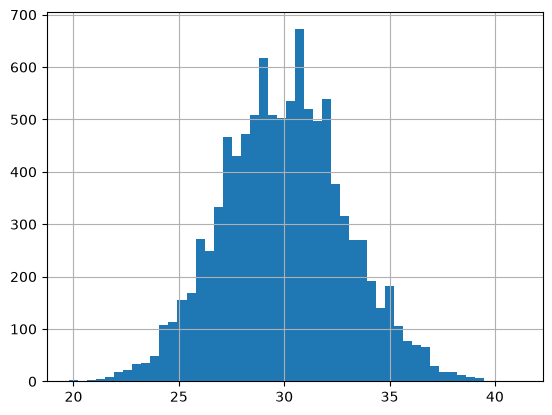

In [7]:
df['fuel_efficiency_mpg'].hist(bins=50);

## Q1

In [8]:
df.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## Q2

In [9]:
df['horsepower'].median()

np.float64(254.0)

## shuffle and split for train, test and validation

In [10]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [11]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [13]:
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

df_train.drop('fuel_efficiency_mpg', axis=1, inplace=True)
df_val.drop('fuel_efficiency_mpg', axis=1, inplace=True)
df_test.drop('fuel_efficiency_mpg', axis=1, inplace=True)

## Q3

In [19]:
w0, w = train_linear_regression(df_train.fillna(0).values, y_train)

y_pred = w0 + df_val.fillna(0).values.dot(w)

print("Validation RMSE:", round(rmse(y_val, y_pred), 4))

Validation RMSE: 2.2053


In [20]:
w0, w = train_linear_regression(df_train.fillna(df_train.mean()).values, y_train)

y_pred = w0 + df_val.fillna(df_train.mean()).values.dot(w)

print("Validation RMSE:", round(rmse(y_val, y_pred), 4))

Validation RMSE: 2.2018


## Q4

In [18]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [21]:
r = [0, 0.01, 0.1, 1, 5, 10, 100]

for r in r:
    w0, w = train_linear_regression_reg(df_train.fillna(0).values, y_train, r=r)
    y_pred = w0 + df_val.fillna(0).values.dot(w)
    print("r =", r, "Val RMSE:", round(rmse(y_val, y_pred), 4))

r = 0 Val RMSE: 2.2053
r = 0.01 Val RMSE: 2.2058
r = 0.1 Val RMSE: 2.2241
r = 1 Val RMSE: 2.3492
r = 5 Val RMSE: 2.4094
r = 10 Val RMSE: 2.4195
r = 100 Val RMSE: 2.4292


## Q5

In [24]:
seed = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

score = []

for s in seed:
    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values
    y_test = df_test['fuel_efficiency_mpg'].values

    df_train.drop('fuel_efficiency_mpg', axis=1, inplace=True)
    df_val.drop('fuel_efficiency_mpg', axis=1, inplace=True)
    df_test.drop('fuel_efficiency_mpg', axis=1, inplace=True)

    w0, w = train_linear_regression(df_train.fillna(0).values, y_train)

    y_pred = w0 + df_val.fillna(0).values.dot(w)

    score.append(rmse(y_val, y_pred))


print("Scores:", score)
print("STD:", round(np.std(score), 3))

    

Scores: [np.float64(2.2392041430461465), np.float64(2.2021128210838907), np.float64(2.163419778753095), np.float64(2.2043588768539144), np.float64(2.2018800943312926), np.float64(2.2457851509084974), np.float64(2.269721207952404), np.float64(2.190794599933433), np.float64(2.2166112016864443), np.float64(2.207036592817851)]
STD: 0.029


## Q6

In [26]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

df_train.drop('fuel_efficiency_mpg', axis=1, inplace=True)
df_val.drop('fuel_efficiency_mpg', axis=1, inplace=True)
df_test.drop('fuel_efficiency_mpg', axis=1, inplace=True)

w0, w = train_linear_regression_reg(df_train.fillna(0).values, y_train, r=0.001)

y_pred = w0 + df_val.fillna(0).values.dot(w)
y_test_pred = w0 + df_test.fillna(0).values.dot(w)

print("Validation RMSE:", round(rmse(y_val, y_pred), 3))
print("Test RMSE:", round(rmse(y_test, y_test_pred), 3))

Validation RMSE: 2.207
Test RMSE: 2.236
